<a href="https://colab.research.google.com/github/ingkapat/Thai-Scam-Call-Detector/blob/main/compare_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install dependencies
!pip install -q scikit-learn matplotlib seaborn

In [2]:
# Cell 2: Mount Drive + paths config
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DRIVE_BASE     = '/content/drive/MyDrive/ThaiScamCall'
RUNS_BASELINES = f'{DRIVE_BASE}/runs/baselines'
RUNS_TEXT      = f'{DRIVE_BASE}/runs/text_cls'
RUNS_E2E       = f'{DRIVE_BASE}/runs/e2e'

sns.set_theme(style='whitegrid')

Mounted at /content/drive


In [3]:
# Cell 3: Load test predictions ทั้ง 3 กลุ่ม
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, accuracy_score,
                             precision_score, recall_score)

results = {}
for root, prefix in [(RUNS_BASELINES, 'Baseline'),
                     (RUNS_TEXT,      'TwoStage'),
                     (RUNS_E2E,       'E2E')]:
    if not os.path.exists(root): continue
    for combo in sorted(os.listdir(root)):
        p = f'{root}/{combo}/test_predictions.csv'
        if os.path.exists(p):
            results[f'{prefix}/{combo}'] = pd.read_csv(p)

print(f'Loaded {len(results)} runs:')
for k in results: print('  ', k)

Loaded 8 runs:
   Baseline/majority
   Baseline/mfcc_lr
   Baseline/mfcc_rf
   Baseline/random
   Baseline/tfidf_lr_thonburian
   E2E/wavlm
   E2E/whisper_enc
   E2E/xlsr


In [4]:
# Cell 4: Summary metrics table (เรียงตาม macro_f1)
rows = []
for name, d in results.items():
    y, p, s = d.label.values, d.pred.values, d.prob_scam.values
    rows.append({
        'model':          name,
        'accuracy':       accuracy_score(y, p),
        'macro_f1':       f1_score(y, p, average='macro'),
        'precision_scam': precision_score(y, p),
        'recall_scam':    recall_score(y, p),
        'f1_scam':        f1_score(y, p),
        'roc_auc':        roc_auc_score(y, s),
        'pr_auc':         average_precision_score(y, s),
    })
metrics_df = pd.DataFrame(rows).sort_values('macro_f1', ascending=False).round(4)
display(metrics_df)
metrics_df.to_csv(f'{DRIVE_BASE}/runs/summary_metrics.csv', index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model,accuracy,macro_f1,precision_scam,recall_scam,f1_scam,roc_auc,pr_auc
6,E2E/whisper_enc,0.9901,0.9901,0.9901,0.9891,0.9896,0.9998,0.9997
4,Baseline/tfidf_lr_thonburian,0.9897,0.9896,0.9950,0.9832,0.9891,0.9996,0.9996
5,E2E/wavlm,0.9831,0.9831,0.9813,0.9832,0.9822,0.9988,0.9988
7,E2E/xlsr,0.9807,0.9807,0.9860,0.9733,0.9796,0.9978,0.9979
2,Baseline/mfcc_rf,0.6628,0.6599,0.6602,0.6002,0.6287,0.7366,0.7151
1,Baseline/mfcc_lr,0.6322,0.6300,0.6208,0.5834,0.6015,0.6820,0.6293
3,Baseline/random,0.5087,0.5081,0.4842,0.4995,0.4917,0.4827,0.4582
0,Baseline/majority,0.5242,0.3439,0.0000,0.0000,0.0000,0.5000,0.4758


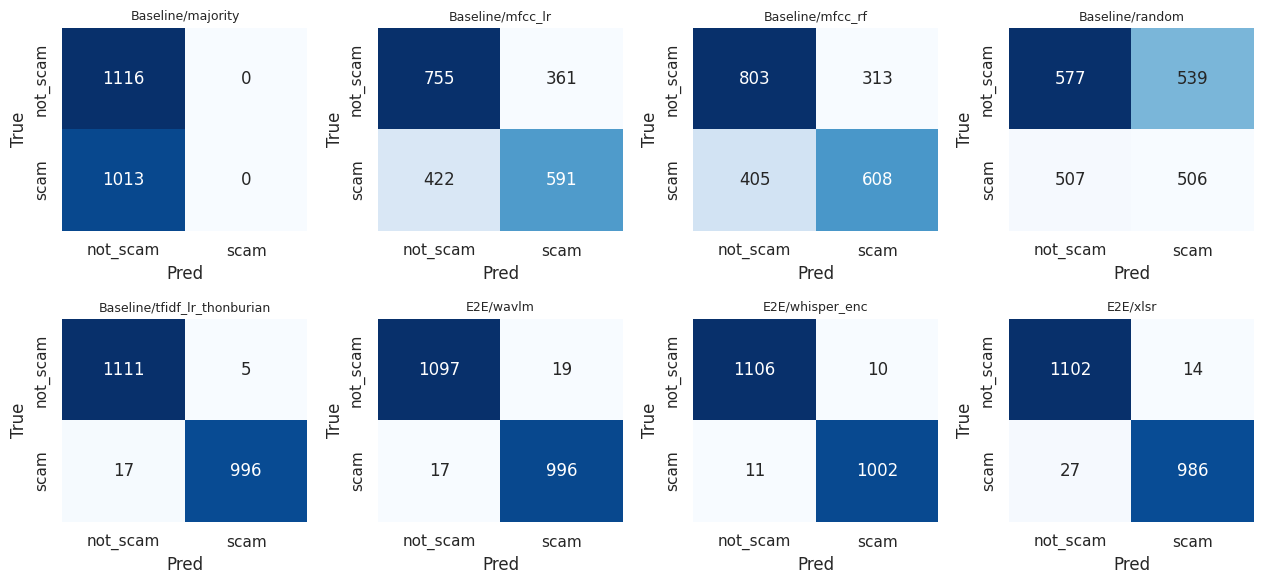

In [5]:
# Cell 5: Confusion matrices grid (ทุก model)
n = len(results)
cols = 4
rows_n = (n + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3.2, rows_n * 3))
axes = np.atleast_2d(axes)
for i, (name, d) in enumerate(results.items()):
    ax = axes[i // cols, i % cols]
    cm = confusion_matrix(d.label, d.pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['not_scam', 'scam'], yticklabels=['not_scam', 'scam'])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Pred'); ax.set_ylabel('True')
for j in range(i + 1, rows_n * cols):
    axes[j // cols, j % cols].axis('off')
plt.tight_layout(); plt.show()

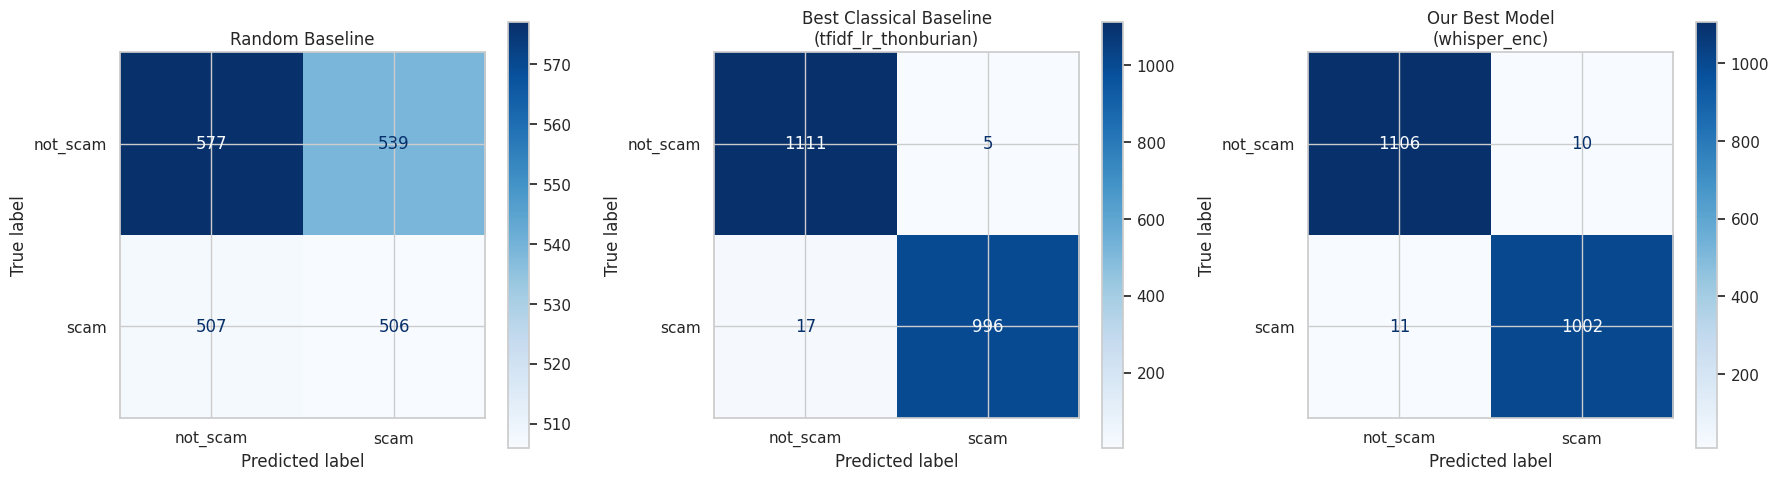

saved -> /content/drive/MyDrive/ThaiScamCall/runs/confusion_3panel.png


In [6]:
# Cell 5b: 3-panel confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

CLASS_LABELS = [0, 1]   # 0=not_scam, 1=scam
DISPLAY_NAMES = ['not_scam', 'scam']

# หา best models อัตโนมัติ
def pick_best(prefix_filter):
    candidates = [(k, f1_score(v.label, v.pred, average='macro'))
                  for k, v in results.items() if prefix_filter(k)]
    return max(candidates, key=lambda x: x[1])[0] if candidates else None

random_key = 'Baseline/random' if 'Baseline/random' in results else None
best_baseline_key = pick_best(lambda k: k.startswith('Baseline/')
                               and not k.endswith('/random')
                               and not k.endswith('/majority'))
best_deep_key = pick_best(lambda k: k.startswith('TwoStage/') or k.startswith('E2E/'))

panels = [
    ('Random Baseline', random_key),
    (f'Best Classical Baseline\n({best_baseline_key.split("/")[-1] if best_baseline_key else "—"})',
     best_baseline_key),
    (f'Our Best Model\n({best_deep_key.split("/")[-1] if best_deep_key else "—"})',
     best_deep_key),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, key) in zip(axes, panels):
    if key is None:
        ax.axis('off'); ax.set_title(f'{title} (no data)'); continue
    d = results[key]
    ConfusionMatrixDisplay.from_predictions(
        d.label, d.pred,
        labels=CLASS_LABELS,
        display_labels=DISPLAY_NAMES,
        ax=ax, cmap='Blues',
    )
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/runs/confusion_3panel.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {DRIVE_BASE}/runs/confusion_3panel.png')

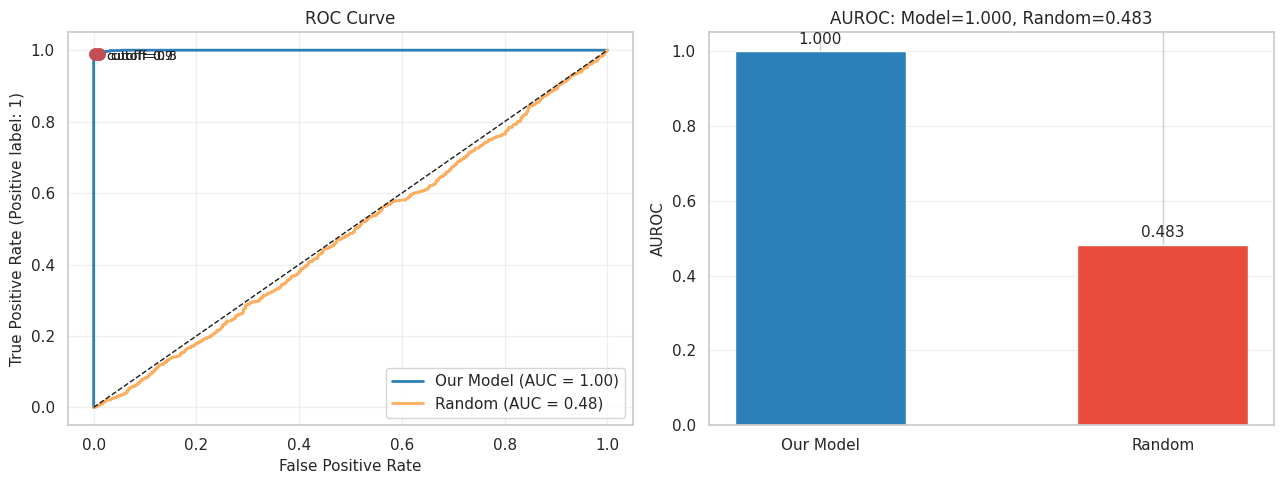

saved -> /content/drive/MyDrive/ThaiScamCall/runs/roc_auroc.png


In [7]:
# Cell 6b: ROC curve + AUROC bar
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# === Left: ROC curve เทียบ Our Best Model vs Random ===
plot_pairs = []
if best_deep_key:
    plot_pairs.append(('Our Model', best_deep_key, '#2c7fb8'))
if random_key:
    plot_pairs.append(('Random', random_key, '#fdae61'))

aucs = {}
for label, key, color in plot_pairs:
    d = results[key]
    fpr, tpr, thresh = roc_curve(d.label, d.prob_scam)
    auc_val = roc_auc_score(d.label, d.prob_scam)
    aucs[label] = auc_val
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{label} (AUC = {auc_val:.2f})')

# Add cutoff markers ที่ Our Model
if best_deep_key:
    d = results[best_deep_key]
    fpr, tpr, thresh = roc_curve(d.label, d.prob_scam)
    for cutoff in [0.3, 0.5, 0.7, 0.9]:
        idx = np.argmin(np.abs(thresh - cutoff))
        axes[0].plot(fpr[idx], tpr[idx], 'ro', markersize=8)
        axes[0].annotate(f'cutoff={cutoff}',
                         xy=(fpr[idx], tpr[idx]),
                         xytext=(8, -4), textcoords='offset points',
                         fontsize=9)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Positive label: 1)', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# === Right: AUROC bar chart ===
if len(aucs) >= 2:
    labels = list(aucs.keys())
    values = list(aucs.values())
    colors_bar = ['#2c7fb8', '#e74c3c']
    axes[1].bar(labels, values, color=colors_bar[:len(labels)], width=0.5)
    axes[1].set_ylabel('AUROC', fontsize=11)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f'AUROC: Model={aucs.get("Our Model", 0):.3f}, '
                      f'Random={aucs.get("Random", 0):.3f}', fontsize=12)
    axes[1].grid(alpha=0.3, axis='y')
    for i, v in enumerate(values):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/runs/roc_auroc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {DRIVE_BASE}/runs/roc_auroc.png')

In [10]:
# Cell 7: Error analysis — ไฟล์ที่ทุกโมเดล (ไม่นับ trivial) พลาด
use_results = {k: v for k, v in results.items()
               if not k.endswith('/majority') and not k.endswith('/random')}

if len(use_results) >= 2:
    base = None
    for name, d in use_results.items():
        sub = d[['filename', 'label', 'pred']].rename(columns={'pred': f'pred_{name}'})
        base = sub if base is None else base.merge(sub.drop(columns=['label']), on='filename')
    pred_cols = [c for c in base.columns if c.startswith('pred_')]
    base['all_wrong'] = base.apply(
        lambda r: all(r[c] != r.label for c in pred_cols), axis=1)
    hard = base[base.all_wrong]
    print(f'ไฟล์ที่ทุกโมเดลพลาด: {len(hard)} / {len(base)}  ({100*len(hard)/len(base):.1f}%)')
    display(hard.head(15))
    hard.to_csv(f'{DRIVE_BASE}/runs/hard_examples.csv', index=False)
else:
    print('ต้องมีอย่างน้อย 2 โมเดล (ไม่นับ trivial) ถึงจะหา hard examples ได้')

ไฟล์ที่ทุกโมเดลพลาด: 6 / 2129  (0.3%)


,filename,label,pred_Baseline/mfcc_lr,pred_Baseline/mfcc_rf,pred_Baseline/tfidf_lr_thonburian,pred_E2E/wavlm,pred_E2E/whisper_enc,pred_E2E/xlsr,all_wrong
609,conv_07391_label1.mp3,1,0,0,0,0,0,0,True
719,conv_19003_label1.mp3,1,0,0,0,0,0,0,True
950,conv_03242_label1.mp3,1,0,0,0,0,0,0,True
1028,conv_17036_label0.mp3,0,1,1,1,1,1,1,True
1106,conv_01831_label1.mp3,1,0,0,0,0,0,0,True
1111,conv_17743_label1.mp3,1,0,0,0,0,0,0,True
